# ruleofthumb — image quickstart

Hello-world example on **dummy data**: explain a black-box image classifier
that consumes `(N, channels, height, width)` inputs.

`RoTImage` shares importance weights across spatial locations, so the
surrogate produces a spatial importance map per channel — and one fitted
model can score images of any size one sample at a time.

In [1]:
import numpy as np
import torch

rng = np.random.RandomState(0)

n, channels, height, width = 32, 3, 8, 8
x = rng.randn(n, channels, height, width).astype(np.float32)

# Stand-in for the black-box classifier's predictions: the left half of the
# image decides the class, so a good explanation should highlight it.
y_outputs = torch.from_numpy((x[:, :, :, : width // 2].mean(axis=(1, 2, 3)) > 0).astype(np.int64))
print(x.shape, y_outputs.shape)

(32, 3, 8, 8) torch.Size([32])


In [2]:
import ruleofthumb

exp = ruleofthumb.fit_image(y_outputs=y_outputs, x_inputs=x, epochs=50, batch_size=32, learning_rate=0.01)

In [3]:
scores = exp.score(torch.from_numpy(x))            # shape [N, classes]
preds = exp.predict(torch.from_numpy(x)).cpu()     # shape [N] (host side)
accuracy = (preds == y_outputs).float().mean().item()
print(f"surrogate accuracy vs black-box labels: {accuracy:.2f}")

surrogate accuracy vs black-box labels: 0.72


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.5529897..2.3831449].


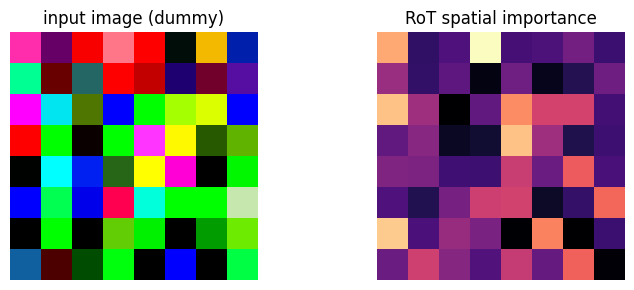

In [4]:
import matplotlib.pyplot as plt

# signed per-pixel importances (channels summed per pixel); magnitude
# heatmap below is a display view for ranking, not the explanation itself
imp = exp.get_explanation(x[:1])                   # [1, H, W] numpy
heat = np.abs(imp[0])                              # magnitude view -> [H, W]

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(x[0].transpose(1, 2, 0), cmap="grey")
axes[0].set_title("input image (dummy)")
axes[1].imshow(heat, cmap="magma")
axes[1].set_title("RoT spatial importance")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Signed saliency overlay

`plot.saliency` overlays the **signed** importance map onto the image
(the magnitude heatmap above is only a ranking view): red pixels push
toward the predicted class, blue against.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.5529897..2.3831449].


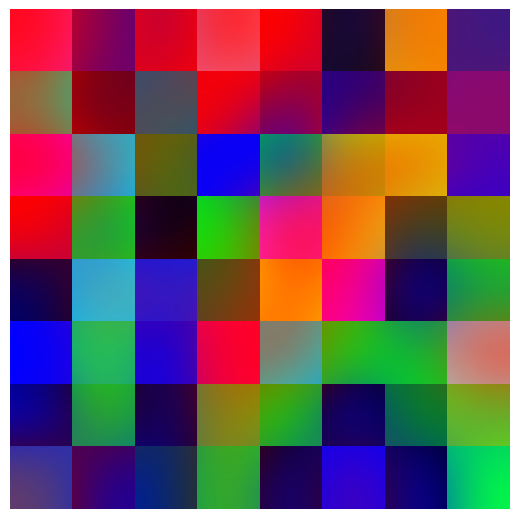

In [5]:
from ruleofthumb import plot

imp_signed = exp.get_explanation(x[:1])[0]   # [H, W], channels summed
fig = plot.saliency(imp_signed, image=x[0].transpose(1, 2, 0))
